## Carregando o dataset

In [1]:
%ls

data/  notebook.ipynb


In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

# Carregar os datasets
df_treino = pd.read_csv('data/dados_treino.csv')
df_teste = pd.read_csv('data/dados_teste.csv')
print(f"Dimensões dataset treino:{df_treino.shape}")
print(f"Dimensões dataset teste:{df_teste.shape}")

Dimensões dataset treino:(16800, 42)
Dimensões dataset teste:(4200, 42)


In [3]:
df_teste.head()

,Unnamed: 0,NU_ANO,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,SITUACAO_AGRUPADA
0,44771,2023,0.0,0.0,33,1560,1507.0,True,False,False,False,True,True,False,False,True,True,False,False,True,True,False,False,True,False,True,False,True,True,False,True,False,True,False,False,False,False,True,False,False,False,1
1,51158,2023,1.0,1.0,35,33,2.0,False,True,False,False,True,True,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,0
2,45137,2023,4.0,4.0,29,0,0.0,True,False,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,True,False,0
3,21164,2023,0.0,0.0,29,0,0.0,False,True,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,0
4,67278,2023,2.0,2.0,31,0,1.0,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False,0


### Vamos remover a coluna de ID do dataset de treino e teste e remover a coluna de 'NU_ANO' por semrpe ser diferente entre amostras de treino e testes

In [35]:
# Removo a coluna de indexação
df_treino = df_treino.drop(columns=['Unnamed: 0'], errors='ignore')
df_teste = df_teste.drop(columns=['Unnamed: 0'], errors='ignore')

# faço one hot encoding da coluna NU_ANO
df_treino = df_treino.drop(columns=['NU_ANO'], errors='ignore')
df_teste = df_teste.drop(columns=['NU_ANO'], errors='ignore')
df_treino, df_teste = df_treino.align(df_teste, join='outer', axis=1, fill_value=0)

In [36]:
df_teste.head()

,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,AGRAVTABAC_1,AGRAVTABAC_2,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023,BENEF_GOV_1.0,BENEF_GOV_2.0,CS_RACA_1,CS_RACA_2,CS_RACA_4,CS_SEXO_F,CS_SEXO_M,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,FORMA_1,FORMA_2,IDADE_ANOS,NU_COMU_EX,NU_CONTATO,POP_LIBER_1.0,POP_LIBER_2.0,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,SITUACAO_AGRUPADA,TEMPO_DE_INICIO_TRATAMENTO,TEMPO_DE_NOTI,TRATSUP_AT_1.0,TRATSUP_AT_2.0
0,0,1,1,0,0,1,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,1,0,1,0,0,0,1,0,-0.632242,0.0,-0.610290,0,1,1,0,0,0,0,1,21.878879,34.006419,0,1
1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,1,0,-0.515617,1.0,-0.427325,0,1,0,0,0,1,0,0,-0.087034,0.475460,0,1
2,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,-0.865491,4.0,0.121569,0,1,0,0,0,0,1,0,-0.116224,-0.249178,0,1
3,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,1,1,0,0,0,1,0,-0.865491,0.0,-0.610290,1,0,0,0,0,1,0,0,-0.116224,-0.249178,0,1
4,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,-0.748867,2.0,-0.244361,0,1,0,0,1,0,0,0,-0.101629,-0.249178,1,0


### Separação de Features

Para o treinamento do modelo, as variáveis foram separadas em três grupos:

- **Features Regressivas**: variáveis contínuas ou numéricas utilizadas como preditores principais.
- **Feature Alvo**: variável que será prevista pelo modelo. Neste caso, `SITUACAO_AGRUPADA`.
- **Features Classificativas**: variáveis categóricas já na forma de one-hot

In [37]:
features_regressivas = ["NU_CONTATO", "IDADE_ANOS", "TEMPO_DE_NOTI", "TEMPO_DE_INICIO_TRATAMENTO"]
target = "SITUACAO_AGRUPADA"
features_classificativas = [col for col in df_treino.columns if col not in features_regressivas + [target]]

### Verificando se há interseção entre colunas:

In [38]:
# Transforma tudo em conjuntos
regressivas = set(features_regressivas)
classificativas = set(features_classificativas)
todas_colunas = set(df_treino.columns)
target_set = {target}

# Testa se não há interseção
sem_interseção = regressivas.isdisjoint(classificativas)

# Testa se a união cobre todas as colunas (exceto o target)
cobre_tudo = regressivas.union(classificativas, target_set) == todas_colunas

# Resultado final
if sem_interseção and cobre_tudo:
    print("Tudo certo: sem interseção e todas as colunas cobertas.")
else:
    print("Há sobreposição ou colunas faltando.")


Tudo certo: sem interseção e todas as colunas cobertas.


### Verificando se os datasets têm colunas iguais

In [39]:
df_treino.columns.equals(df_teste.columns)

True

## Lidando com dados ausentes

### Procurando as colunas com valores nulos em cada coluna

Porcentagem de valores nulos no treino (%):
AGRAVAIDS_1.0                 0.0
AGRAVAIDS_2.0                 0.0
AGRAVALCOO_1.0                0.0
AGRAVALCOO_2.0                0.0
AGRAVDIABE_1.0                0.0
AGRAVDIABE_2.0                0.0
AGRAVDROGA_1                  0.0
AGRAVDROGA_2                  0.0
AGRAVOUTRA_1.0                0.0
AGRAVOUTRA_2.0                0.0
AGRAVTABAC_1                  0.0
AGRAVTABAC_2                  0.0
ANO_2019                      0.0
ANO_2020                      0.0
ANO_2021                      0.0
ANO_2022                      0.0
ANO_2023                      0.0
BENEF_GOV_1.0                 0.0
BENEF_GOV_2.0                 0.0
CS_RACA_1                     0.0
CS_RACA_2                     0.0
CS_RACA_4                     0.0
CS_SEXO_F                     0.0
CS_SEXO_M                     0.0
ESCOL_CATEGORIZADA_0          0.0
ESCOL_CATEGORIZADA_1          0.0
ESCOL_CATEGORIZADA_2          0.0
ESCOL_CATEGORIZADA_3          0.0
FORM

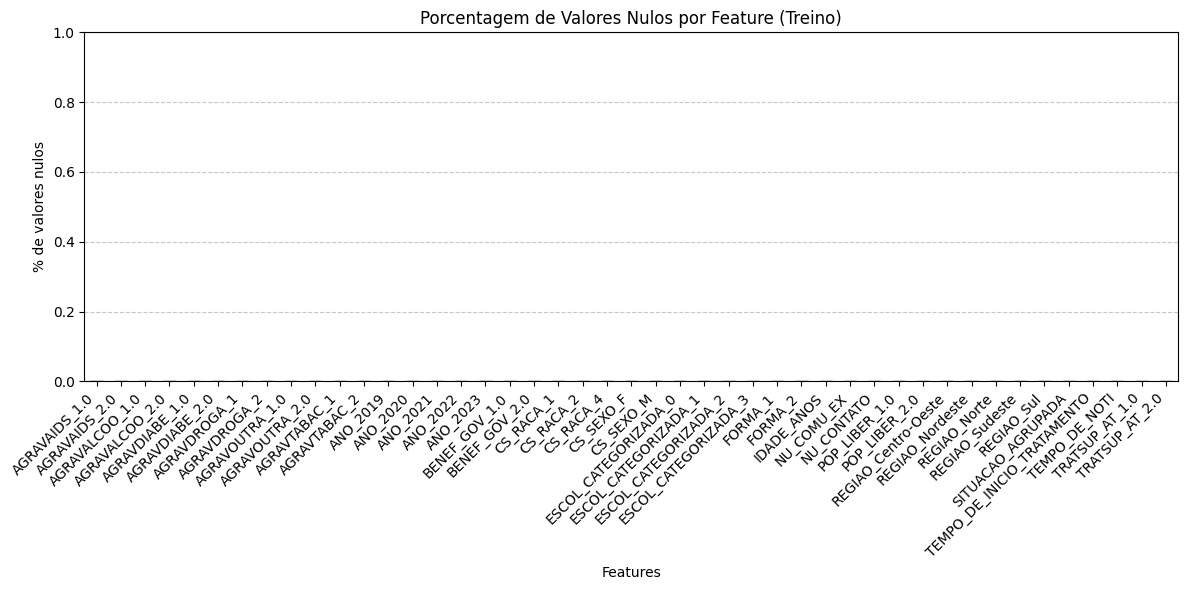

In [40]:
import matplotlib.pyplot as plt

# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))


# Plotando qtd de valores nulos
null_percent = (df_treino.isnull().sum() / len(df_treino) * 100).round(2)
null_percent = null_percent.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
null_percent.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porcentagem de Valores Nulos por Feature (Treino)')
plt.ylabel('% de valores nulos')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(null_percent.max(), 1))  # Garantir alguma altura mínima visível
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como todas as colunas apresentam **menos de 5% de valores faltantes**, **nenhuma será removida**. Em vez disso, optamos por **imputar os valores ausentes com base na estrutura dos dados**, de forma a preservar a informação e reduzir viés:

* **Features Classificativas:** preenchidas com a moda dos valores da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.
* **Features Regressivas:** preenchidas com a média por grupo da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.

> **Observação:** não há casos com valores nulos na variável alvo `SITUACAO_AGRUPADA`.


In [41]:
# Transformar classificações: True/False → 1/0 (sem alterar NaNs)
for col in features_classificativas:
    df_treino[col] = df_treino[col].apply(lambda x: int(x) if pd.notnull(x) else x)
    df_teste[col] = df_teste[col].apply(lambda x: int(x) if pd.notnull(x) else x)

# Transformar colunas de regressão: int → float (sem alterar NaNs)
for col in features_regressivas:
    df_treino[col] = df_treino[col].astype(float)
    df_teste[col] = df_teste[col].astype(float)

# Obter a lista de colunas com valores nulos
colunas_com_nulos = df_treino.columns[df_treino.isnull().any()].tolist()

for col in colunas_com_nulos:
    if col in features_classificativas:  # Coluna categórica (binária)
        modos = df_treino.groupby('SITUACAO_AGRUPADA')[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 0)
        df_treino[col] = df_treino.apply(
            lambda row: modos[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: modos.get(row['SITUACAO_AGRUPADA'], 0) if pd.isnull(row[col]) else row[col], axis=1
        )

    elif col in features_regressivas:  # Coluna numérica (regressiva)
        medias = df_treino.groupby('SITUACAO_AGRUPADA')[col].mean()
        media_global = df_treino[col].mean()
        df_treino[col] = df_treino.apply(
            lambda row: medias[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: medias.get(row['SITUACAO_AGRUPADA'], media_global) if pd.isnull(row[col]) else row[col], axis=1
        )


In [42]:
# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))

Porcentagem de valores nulos no treino (%):
AGRAVAIDS_1.0                 0.0
AGRAVAIDS_2.0                 0.0
AGRAVALCOO_1.0                0.0
AGRAVALCOO_2.0                0.0
AGRAVDIABE_1.0                0.0
AGRAVDIABE_2.0                0.0
AGRAVDROGA_1                  0.0
AGRAVDROGA_2                  0.0
AGRAVOUTRA_1.0                0.0
AGRAVOUTRA_2.0                0.0
AGRAVTABAC_1                  0.0
AGRAVTABAC_2                  0.0
ANO_2019                      0.0
ANO_2020                      0.0
ANO_2021                      0.0
ANO_2022                      0.0
ANO_2023                      0.0
BENEF_GOV_1.0                 0.0
BENEF_GOV_2.0                 0.0
CS_RACA_1                     0.0
CS_RACA_2                     0.0
CS_RACA_4                     0.0
CS_SEXO_F                     0.0
CS_SEXO_M                     0.0
ESCOL_CATEGORIZADA_0          0.0
ESCOL_CATEGORIZADA_1          0.0
ESCOL_CATEGORIZADA_2          0.0
ESCOL_CATEGORIZADA_3          0.0
FORM

## Normalizando as features regresssivas

In [43]:
df_teste.head()

,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,AGRAVTABAC_1,AGRAVTABAC_2,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023,BENEF_GOV_1.0,BENEF_GOV_2.0,CS_RACA_1,CS_RACA_2,CS_RACA_4,CS_SEXO_F,CS_SEXO_M,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,FORMA_1,FORMA_2,IDADE_ANOS,NU_COMU_EX,NU_CONTATO,POP_LIBER_1.0,POP_LIBER_2.0,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,SITUACAO_AGRUPADA,TEMPO_DE_INICIO_TRATAMENTO,TEMPO_DE_NOTI,TRATSUP_AT_1.0,TRATSUP_AT_2.0
0,0,1,1,0,0,1,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,1,0,1,0,0,0,1,0,-0.632242,0,-0.610290,0,1,1,0,0,0,0,1,21.878879,34.006419,0,1
1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,1,0,-0.515617,1,-0.427325,0,1,0,0,0,1,0,0,-0.087034,0.475460,0,1
2,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,-0.865491,4,0.121569,0,1,0,0,0,0,1,0,-0.116224,-0.249178,0,1
3,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,1,1,0,0,0,1,0,-0.865491,0,-0.610290,1,0,0,0,0,1,0,0,-0.116224,-0.249178,0,1
4,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,-0.748867,2,-0.244361,0,1,0,0,1,0,0,0,-0.101629,-0.249178,1,0


Decidimos aplicar a **normalização z-score** (também chamada de padronização) às features regressivas para garantir que todas as variáveis numéricas estejam na mesma escala. Essa normalização evita que variáveis com médias ou desvios padrões muito distintos tenham influência desproporcional no treinamento do modelo.

A normalização foi feita utilizando apenas as médias e desvios padrões calculados no conjunto de treino, sendo aplicada tanto ao conjunto de treino quanto ao de teste. Essa prática é importante para evitar **vazamento de informação (data leakage)**, garantindo que o modelo não tenha acesso a informações do conjunto de teste durante o treinamento.


In [44]:
medias = df_treino[features_regressivas].mean()
desvios = df_treino[features_regressivas].std()

df_treino[features_regressivas] = (df_treino[features_regressivas] - medias) / desvios

df_teste[features_regressivas] = (df_teste[features_regressivas] - medias) / desvios

## Separação da variável alvo do restante dos dados de treino e teste

In [45]:
X_treino = df_treino.drop(columns=[target])
y_treino = df_treino[target]

X_teste = df_teste.drop(columns=[target])
y_teste = df_teste[target]

In [46]:
X_treino.head()

,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,AGRAVTABAC_1,AGRAVTABAC_2,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023,BENEF_GOV_1.0,BENEF_GOV_2.0,CS_RACA_1,CS_RACA_2,CS_RACA_4,CS_SEXO_F,CS_SEXO_M,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,FORMA_1,FORMA_2,IDADE_ANOS,NU_COMU_EX,NU_CONTATO,POP_LIBER_1.0,POP_LIBER_2.0,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,TEMPO_DE_INICIO_TRATAMENTO,TEMPO_DE_NOTI,TRATSUP_AT_1.0,TRATSUP_AT_2.0
0,1,0,1,0,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,1,0,-1.157053,0,-0.427325,0,1,0,0,1,0,0,0.044324,-0.029591,0,1
1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,1,1,0,0,0,0,1,-0.457305,3,-0.061396,0,1,0,0,0,1,0,0.161086,1.222056,1,0
2,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,1.000505,5,0.304533,0,1,0,1,0,0,0,-0.072438,-0.227219,1,0
3,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0.767256,1,-0.244361,0,1,0,0,0,1,0,-0.101629,-0.227219,1,0
4,0,1,0,1,0,1,1,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,-1.157053,14,1.951215,1,0,0,0,1,0,0,-0.116224,-0.249178,1,0


In [47]:
print("X_treino shape:", X_treino.shape)
print("y_treino shape:", y_treino.shape)
print("X_teste shape:", X_teste.shape)
print("y_teste shape:", y_teste.shape)


X_treino shape: (16800, 44)
y_treino shape: (16800,)
X_teste shape: (4200, 44)
y_teste shape: (4200,)


## Lidando com desbalanceamento de classes

Fomos orientados a procurar resolver o problema de desbalanceamento de classes quando `n_maj > 1.5⋅n_min`

In [48]:
from collections import Counter

# Conta as amostras por classe no y_treino
classe_counts = Counter(y_treino)
n_maj = max(classe_counts.values())
n_min = min(classe_counts.values())

# Verifica a condição
desbalanceado = n_maj > 1.5 * n_min
print(f"Desbalanceado? {desbalanceado} (n_maj = {n_maj}, n_min = {n_min})")

Desbalanceado? True (n_maj = 15136, n_min = 1664)


## Treinar e validar

- **Grid Search com Cross-Validation**:
  - Realiza validação cruzada estratificada (5-folds) para encontrar os melhores hiperparâmetros do modelo informado, testando todas as combinações possíveis entre os hiperparâmetros propostos.
  - Utiliza a métrica `recall macro` para otimizar o modelo, tratando de forma equilibrada as classes mesmo em contextos desbalanceados e evitando **casos falsos negativos**, que são críticos ao predizer óbitos.

> **Obs.:** A matriz de confusão é normalizada por linha (ou seja, por classe real), o que permite visualizar a proporção de exemplos de cada classe que foram corretamente ou incorretamente classificados. Isso é especialmente útil em conjuntos de dados desbalanceados, pois destaca o desempenho do modelo na classe minoritária sem ser ofuscado pela quantidade absoluta de exemplos da classe majoritária.


Além disos precisamos usar um SMOTE por fold, para equilibrar as estimativas

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def plot_matriz_confusao_normalizada(y_verdadeiro, y_predito, nome_modelo):
    # Matriz de confusão normalizada por linha
    cm = confusion_matrix(y_verdadeiro, y_predito)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Nomes das classes
    labels = ['Classe 0', 'Classe 1']
    cm_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"Matriz de Confusão Normalizada - {nome_modelo}")
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.show()
    
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
import pandas as pd

def avaliar_modelo_cv(modelo_base, params, nome):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Pipeline: SMOTE será aplicado em cada fold
    pipeline = make_pipeline(
        SMOTE(random_state=42),
        modelo_base
    )

    # Dicionário de métricas
    scoring = {
        'recall_1': make_scorer(recall_score, pos_label=1),
        'precision_macro': 'precision_macro',
        'f1_macro': 'f1_macro',
        'accuracy': 'accuracy'
    }

    # Ajustar nomes dos parâmetros para usarem o prefixo do modelo dentro da pipeline
    nome_etapa = pipeline.steps[-1][0]  # Ex: 'randomforestclassifier'
    params_pipeline = {f'{nome_etapa}__{k}': v for k, v in params.items()}

    # GridSearch com refit baseado no recall_macro
    grid = GridSearchCV(pipeline, params_pipeline, cv=cv, scoring=scoring, refit='recall_1', n_jobs=-1)
    grid.fit(X_treino, y_treino)  # Agora com treino desbalanceado

    print(f"\n[Validação cruzada] Modelo: {nome}")
    print("Melhores hiperparâmetros encontrados:", grid.best_params_)
    print(f"Melhor : {grid.best_score_:.4f}\n")

    # Criar DataFrame com as métricas
    resultados = pd.DataFrame(grid.cv_results_)
    metricas = resultados[[
        'params',
        'mean_test_recall_1',
        'mean_test_precision_macro',
        'mean_test_f1_macro',
        'mean_test_accuracy'
    ]]

    metricas = metricas.sort_values(by='mean_test_recall_1', ascending=False)

    print("Top combinações por recall_1:")
    display(metricas.head(5))

    return grid.best_estimator_, grid.best_score_

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

def plot_precision_recall_vs_threshold(modelo_treinado):
    probs = modelo_treinado.predict_proba(X_teste)[:, 1]
    precisao, recall, thresholds = precision_recall_curve(y_teste, probs)

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisao[:-1], label='Precisão')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precisão e Recall vs Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

from sklearn.metrics import f1_score

def buscar_threshold_otimo(modelo_treinado, X_val, y_val):
    probs = modelo_treinado.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.1, 0.91, 0.1)
    melhor_f1 = 0
    melhor_threshold = 0.5

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_val, preds)
        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_threshold = t

    print(f"Melhor threshold encontrado: {melhor_threshold:.2f} com F1-score = {melhor_f1:.4f}")
    return melhor_threshold

from sklearn.metrics import classification_report, confusion_matrix

def avaliar_em_teste_com_threshold(modelo_treinado, nome_modelo, threshold=0.5):
    # Obter probabilidades da classe positiva (classe 1)
    probs = modelo_treinado.predict_proba(X_teste)[:, 1]
    
    # Classificar com o novo threshold
    y_pred = (probs >= threshold).astype(int)

    print(f"\n[Avaliação com Threshold={threshold:.2f}] Modelo: {nome_modelo}")
    print(classification_report(y_teste, y_pred, digits=4))

    plot_matriz_confusao_normalizada(y_teste, y_pred, nome_modelo)
    
from sklearn.metrics import precision_recall_curve, average_precision_score

def plotar_curva_precision_recall_com_thresholds(modelo_treinado, nome_modelo=""):
    # Probabilidades da classe positiva
    probs = modelo_treinado.predict_proba(X_teste)[:, 1]

    # Calcula precision, recall e thresholds
    precision, recall, thresholds = precision_recall_curve(y_teste, probs)
    ap = average_precision_score(y_teste, probs)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'AP = {ap:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall - {nome_modelo}')
    plt.grid(True)

    # Marcar alguns thresholds no gráfico
    for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
        plt.annotate(f'{thresholds[i]:.2f}', (recall[i], precision[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='green')

    plt.legend(loc='lower left')
    plt.show()



In [61]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
params_knn = {
    'n_neighbors': [1, 5, 10],
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}

knn_best, score_knn = avaliar_modelo_cv(knn, params_knn, "kNN")


[Validação cruzada] Modelo: kNN
Melhores hiperparâmetros encontrados: {'kneighborsclassifier__n_neighbors': 10, 'kneighborsclassifier__p': 2, 'kneighborsclassifier__weights': 'uniform'}
Melhor : 0.4706

Top combinações por recall_1:


,params,mean_test_recall_1,mean_test_precision_macro,mean_test_f1_macro,mean_test_accuracy
10,"{'kneighborsclassifier__n_neighbors': 10, 'kne...",0.470563,0.580641,0.591039,0.789048
11,"{'kneighborsclassifier__n_neighbors': 10, 'kne...",0.469364,0.579711,0.589779,0.787857
8,"{'kneighborsclassifier__n_neighbors': 10, 'kne...",0.453721,0.584076,0.596188,0.799524
9,"{'kneighborsclassifier__n_neighbors': 10, 'kne...",0.451918,0.583259,0.595161,0.798810
6,"{'kneighborsclassifier__n_neighbors': 5, 'knei...",0.441109,0.579621,0.590630,0.796429


In [62]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
params_log = {
    'class_weight': ['balanced', {0: 2, 1: 3}]
}

log_best, score_log = avaliar_modelo_cv(log, params_log, "Regressão Logística")


[Validação cruzada] Modelo: Regressão Logística
Melhores hiperparâmetros encontrados: {'logisticregression__class_weight': {0: 2, 1: 3}}
Melhor : 0.2170

Top combinações por recall_1:


,params,mean_test_recall_1,mean_test_precision_macro,mean_test_f1_macro,mean_test_accuracy
1,"{'logisticregression__class_weight': {0: 2, 1:...",0.216962,0.636957,0.603048,0.883571
0,{'logisticregression__class_weight': 'balanced'},0.115992,0.661220,0.562711,0.896012


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
params_rf = {
    'class_weight':['balanced'],
    'n_estimators': [10, 100, 200],
    'max_depth': [10, 50],
    'min_samples_split': [2, 10, 30],
}
rf_best, score_rf = avaliar_modelo_cv(rf, params_rf, "Random Forest")



[Validação cruzada] Modelo: Random Forest
Melhores hiperparâmetros encontrados: {'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 30, 'randomforestclassifier__n_estimators': 200}
Melhor : 0.4970

Top combinações por recall_1:


,params,mean_test_recall_1,mean_test_precision_macro,mean_test_f1_macro,mean_test_accuracy
8,{'randomforestclassifier__class_weight': 'bala...,0.496995,0.618390,0.637338,0.832917
5,{'randomforestclassifier__class_weight': 'bala...,0.493397,0.618355,0.637322,0.833750
7,{'randomforestclassifier__class_weight': 'bala...,0.492796,0.616311,0.634995,0.831607
0,{'randomforestclassifier__class_weight': 'bala...,0.492190,0.606708,0.624054,0.820476
4,{'randomforestclassifier__class_weight': 'bala...,0.490390,0.617859,0.636644,0.833810


De acordo com o parâmetro de treinamento na kfold cross-validation, a recall_macro, o melhor modelo é o Random Forest com os hiperparâmetros {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 10}, sendo o melhor modelos nas métricas mean_test_precision_macro, mean_test_f1_macro e mean_test_accuracy também.

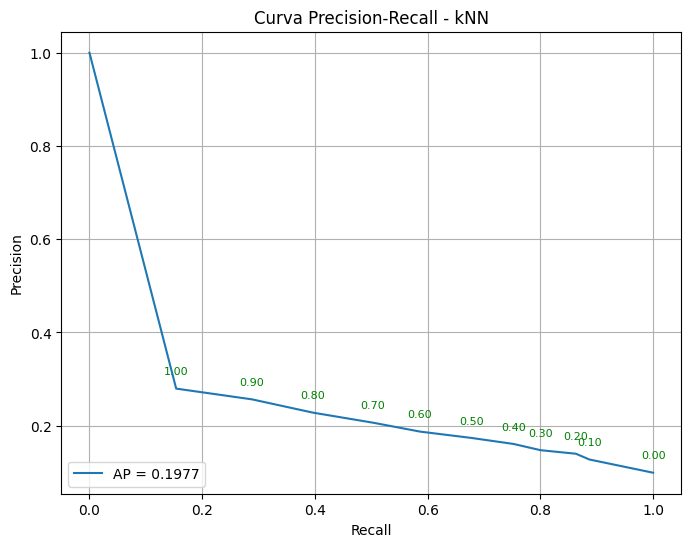

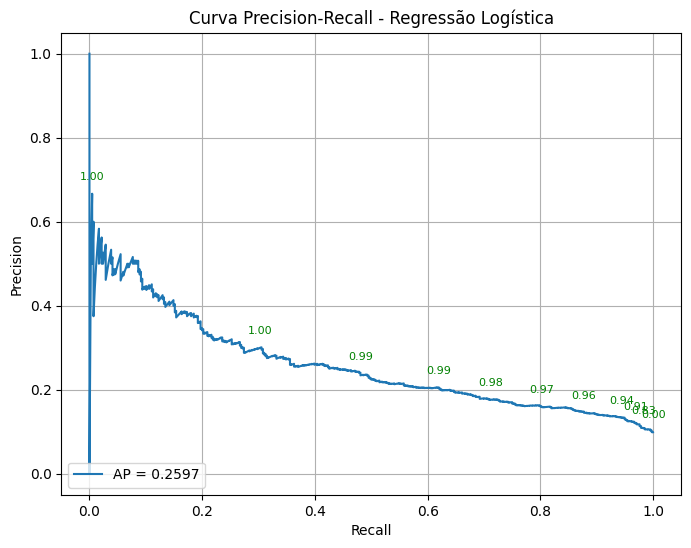

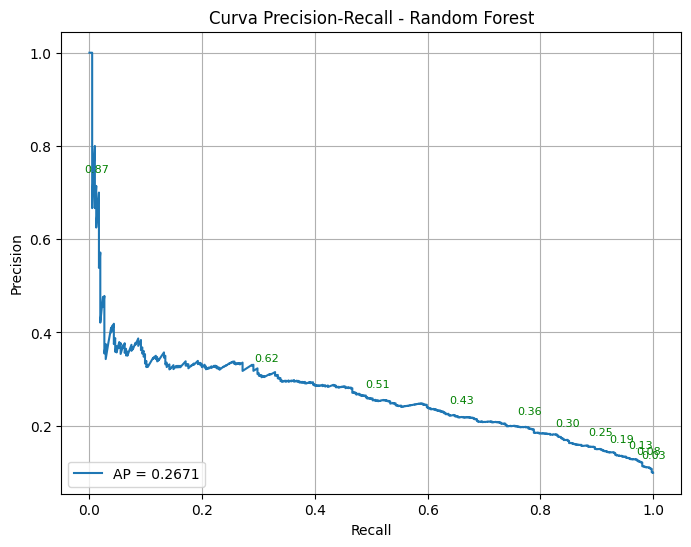

In [64]:
plotar_curva_precision_recall_com_thresholds(knn_best, "kNN")
plotar_curva_precision_recall_com_thresholds(log_best, "Regressão Logística")
plotar_curva_precision_recall_com_thresholds(rf_best, "Random Forest")



[Validação cruzada] Modelo: Random Forest
Melhores hiperparâmetros encontrados: {'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 30, 'randomforestclassifier__n_estimators': 200}
Melhor : 0.4970

Top combinações por recall_1:


,params,mean_test_recall_1,mean_test_precision_macro,mean_test_f1_macro,mean_test_accuracy
8,{'randomforestclassifier__class_weight': 'bala...,0.496995,0.618390,0.637338,0.832917
5,{'randomforestclassifier__class_weight': 'bala...,0.493397,0.618355,0.637322,0.833750
7,{'randomforestclassifier__class_weight': 'bala...,0.492796,0.616311,0.634995,0.831607
0,{'randomforestclassifier__class_weight': 'bala...,0.492190,0.606708,0.624054,0.820476
4,{'randomforestclassifier__class_weight': 'bala...,0.490390,0.617859,0.636644,0.833810


Melhor threshold encontrado: 0.50 com F1-score = 0.4572

[Avaliação com Threshold=0.50] Modelo: Random Forest
              precision    recall  f1-score   support

           0     0.9413    0.8224    0.8779      3784
           1     0.2483    0.5337    0.3389       416

    accuracy                         0.7938      4200
   macro avg     0.5948    0.6780    0.6084      4200
weighted avg     0.8727    0.7938    0.8245      4200



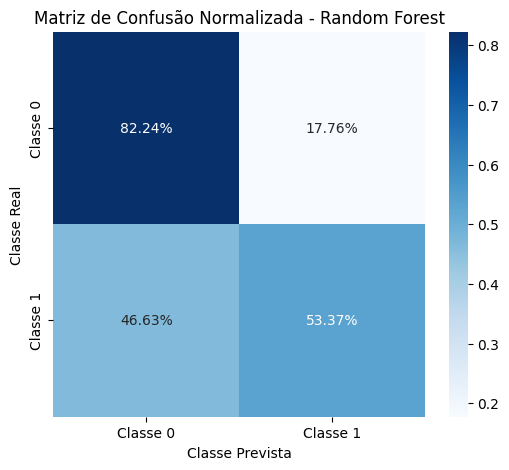

In [ ]:
# Após gridsearch
rf_best, _ = avaliar_modelo_cv(rf, params_rf, "Random Forest")

# Buscar melhor threshold com base no conjunto de teste
threshold_otimo = buscar_threshold_otimo(rf_best, X_treino, y_treino)

# Avaliar no teste com esse threshold
avaliar_em_teste_com_threshold(rf_best, "Random Forest", threshold=0.2)